In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import fastnc
print('fastnc version:', fastnc.__version__)
from fastnc import fastnc, bispectrum

fastnc version: 1.1.25


# Bispectrum

## Instantiate the class:

In [2]:
# Instantiate with config:
config = {'Lmax':30}
bs = bispectrum.BispectrumTATT(config)

# Instantiate with kwargs:
# bs = bispectrum.BispectrumHalofit(Lmax=20)

## Set cosmology:

In [3]:
# This is needed to perform line-of-sight integration over matter bispectrum
# Especially for bispectrum class based on Halofit, we need to supply wCDM model to explicitly set w EoS parameter
# and amplitude of LSS, sigma8, and spectral index, n, need to be includes in the meta data of cosmo instance
# Here we take predefined wCDM model, where w=-1.0, and other cosmological parameter are set to be LCDM values from Planck2018
cosmo = bispectrum.wPlanck18
# Set
bs.set_cosmology(cosmo)

## Set source redshift bin distribution:

In [4]:
# The first argument is the list of redshift bins and 
# the second argument is the list of distribution on the bins.
# The distribution do **not** have to be normalized by user, and
# the code will normalize it internally.

# If the distribution is a delta function, 
# you can set a scalar value for the sample.

# Here is an example:
# The first sample: Gaussian centering at z=1.0
zs_1 = np.arange(0.5, 1.5)
pzs_1= np.exp(-(zs_1-1.0)**2.0/0.1**2/2.0)
# The second sample: delta function at z=2.0
zs_2 = 2.0
pzs_2 = 1.0

# Set the distributions
# The code will name the samples as '0', '1', ... automatically
#bs.set_source_distribution([zs_1], [pzs_1])
bs.set_IA_param({'a1': 1.0, \
                         'alphaIA': 0.0, \
                         'a2': 0.5, \
                         'alphaIA_2': 0.0, \
                         'bias_ta': 1.0, \
                         'z0': 0.62})

# You can use your own name for the samples
# name_1 = 'sample_1'
# name_2 = 'sample_2'
bs.set_source_distribution([zs_1, zs_2], [pzs_1, pzs_2])

# After setting the distribution, you need to run computation
bs.compute_kernel()

## Set linear power spectrum:

In [5]:
# The shape of matter power spectrum is independent of redshift
# and the amplitude is normalized to z=0, so that it gives input sigma8
k, pklin = np.loadtxt('pklin_P18.dat', unpack=True)
bs.set_pklin(k, pklin)
bs.set_pknl(k, pklin)
# linear growth rate is also needed for the computation
z, lgr = np.loadtxt('lgr_P18.dat', unpack=True)
bs.set_lgr(z, lgr)

## Set support range of scale/triangle (optional):

In [15]:
# Set support range of scale:
# This is typically **not** needed because the class already 
# has its own support range by default by developper.
# bs.set_ell1mu_range(ell1min, ell2max, epmu)

## Set window function on bispectrum (optional):

In [16]:
# Set window function multiplied on bispectrum:
# For example, pixel window function for pixelized survey data
# window = lambda ell1, ell2, ell3: np.exp(-(ell1**2+ell2**2+ell3**2)/10**3)
# bs.set_window_function(window)

## Ininialize interpolation of bispectrum:

In [6]:
# This will prepare the interpolation for all the sample combinations
# bs.interpolate()

# If you want to interpolate only specific sample combinations,
# you can tell with scombs keyword, stands for sample combinations.
# This is a list of tuples, each of which is the sample combination.

# For example, if you are interested only in auto bispectrum,
#scombs = [('0','0','0'), ('1','1','1')]
scombs = [0.5, 1]
%time bs.interpolate(scombs=scombs)

CPU times: user 86.7 ms, sys: 11.3 ms, total: 98 ms
Wall time: 97.2 ms


## Getting bispectrum

CPU times: user 5.42 ms, sys: 2.47 ms, total: 7.89 ms
Wall time: 7.18 ms
CPU times: user 2.5 ms, sys: 53 µs, total: 2.56 ms
Wall time: 2.56 ms


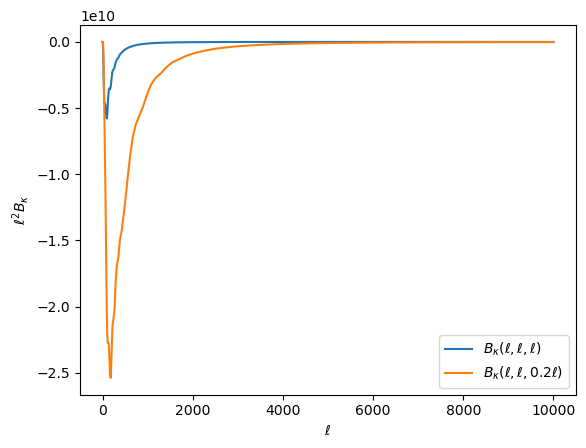

In [7]:
# Get bispectrum
ell = np.logspace(0, 4, 100)

# Example, get kappa bispectrum as a function of scale ell for equilateral triangle
#%time b_kappa_equi = bs.kappa_bispectrum(ell, ell, ell, scomb=('0','0','0'))
%time b_kappa_equi = bs.kappa_bispectrum_IA_direct(ell, ell, ell, scomb=0.5)
# Example, get kappa bispectrum as a function of scale ell for isoceles triangle
#%time b_kappa_isoc = bs.kappa_bispectrum(ell, ell, ell*0.2, scomb=('0','0','0'))
%time b_kappa_isoc = bs.kappa_bispectrum_IA_direct(ell, ell, ell*0.2, scomb=0.5)


plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell^2 B_\kappa$')
plt.plot(ell, ell**2*b_kappa_equi, label=r'$B_\kappa(\ell, \ell, \ell)$')
plt.plot(ell, ell**2*b_kappa_isoc, label=r'$B_\kappa(\ell, \ell, 0.2\ell)$')
plt.legend()
plt.show()

## Initialize multipole:

In [22]:
# This will prepare the interpolation for all the sample combinations
%time bs.decompose(scombs=scombs);

CPU times: user 1.03 s, sys: 1.45 s, total: 2.49 s
Wall time: 667 ms


0

# Natural component

## Instantiate the class

In [23]:
# side length bin
t1_arcmin = np.logspace(0, 2, 20+1)[:-1]
t1_radian = np.deg2rad(t1_arcmin/60.0)
dlnt = np.log(t1_radian[1]/t1_radian[0])
# Opening angle bin
phi = np.linspace(0, np.pi, 30)

# Instantiate with config:
# Note: This will take a long time for the first time to prepare mode-coupling function in cache.
config = {'Lmax':20, 'Mmax':30, 't1':t1_radian, 'phi':phi, 'dlnt':dlnt, 'projection':'cent'}
fnc = fastnc.FastNaturalComponents(config)

# Instantiate with kwargs:
# fnc = fastnc.FastNaturalComponents(Lmax=20, Mmax=40, t1=t1_radian, phi=phi, dlnt=dlnt)

Loading cache from cache at /Users/gchgomes/.fastnc/coupling-1.npz
(L,M) = (20, 30)/651

## Set bispectrum:

In [24]:
fnc.set_bispectrum(bs)

Tuning FFT bins...


## Compute natural components:

In [26]:
# This module does not hold the results for all the sample combinations on memory because this can be huge.
# Instead you need to specify the sample combination you want to compute.
# If you want to get natural components for many sample combinations, 
# you can call this function many times over different sample combinations.
args = dict(scomb = 0.5)
%time fnc.compute(**args)

changing shear projection from x to cent
CPU times: user 333 ms, sys: 56.7 ms, total: 390 ms
Wall time: 389 ms


## Getting the predicted natural component and its multipoles

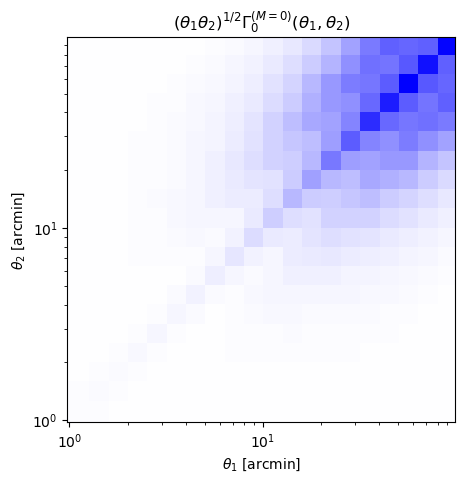

In [27]:
# Access to the natural-component multipoles:
t1, t2, M = fnc.get_bins(bin_type='multipole', t1_unit='arcmin', mesh=False)
Mmax = fnc.config_multipole['Mmax']
Gamma0M = fnc.Gamma0M

# Example: Plotting M=0th multipole of 0-th natural component
plt.figure(figsize=(5,5))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta_1$ [arcmin]')
plt.ylabel(r'$\theta_2$ [arcmin]')
plt.title(r'$(\theta_1\theta_2)^{1/2}\Gamma_0^{(M=0)}(\theta_1, \theta_2)$')
z = Gamma0M[:, :, Mmax]*np.sqrt(t1[:,None]*t2[None,:])
vmax = np.max(np.abs(z))
plt.pcolormesh(t1, t2, z, vmin=-vmax, vmax=vmax, cmap='bwr')
plt.show()

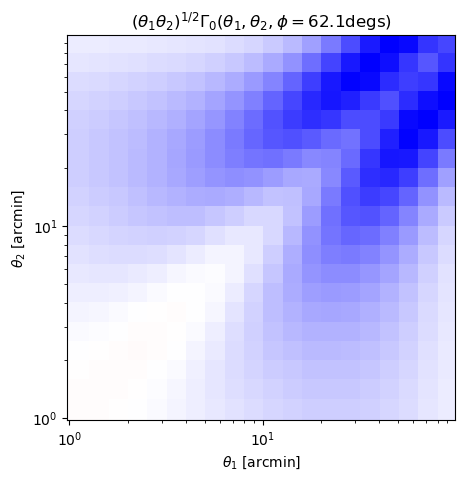

In [28]:
# Access to the natural component:
t1, t2, phi = fnc.get_bins(bin_type='SAS', t1_unit='arcmin', mesh=False)
Gamma0 = fnc.Gamma0

# Example: Plotting of 0-th natural component for phi=pi/3
idx = np.argmin(np.abs(phi - np.pi/3))
plt.figure(figsize=(5,5))
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta_1$ [arcmin]')
plt.ylabel(r'$\theta_2$ [arcmin]')
plt.title(r'$(\theta_1\theta_2)^{{1/2}}\Gamma_0(\theta_1, \theta_2, \phi={:.1f}{{\rm degs}})$'.format(phi[idx]/np.pi*180.0))
z = Gamma0[:, :, idx].real*np.sqrt(t1[:,None]*t2[None,:])
vmax = np.max(np.abs(z))
plt.pcolormesh(t1, t2, z, vmin=-vmax, vmax=vmax, cmap='bwr')
plt.show()

### Mass skewness

In [29]:
R = np.logspace(0, 2, 50)
%time out = fnc.calculateMap3(R, unit='arcmin')

CPU times: user 87.3 ms, sys: 33.8 ms, total: 121 ms
Wall time: 107 ms


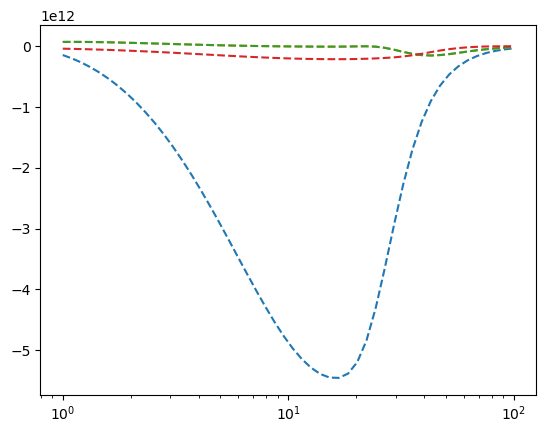

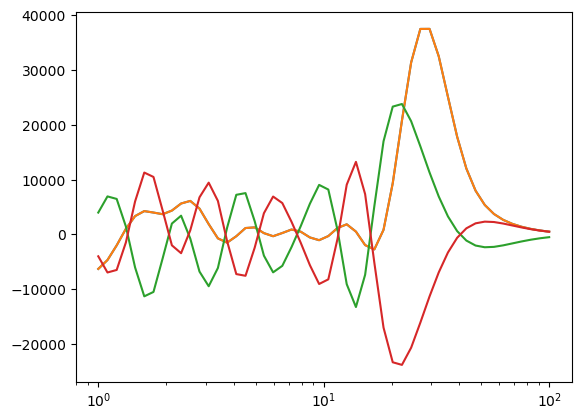

In [30]:
# 0 map3

# 1 mapmapmx
# 2 mapmxmap
# 3 mxmapmap

# 4 mxmxmap
# 5 mxmapmx
# 6 mapmxmx

# 7 mx3
plt.xscale('log')
plt.plot(R, R*out[0], ls='--')
plt.plot(R, R*out[4], ls='--')
plt.plot(R, R*out[5], ls='--')
plt.plot(R, R*out[6], ls='--')
plt.show()

plt.xscale('log')
plt.plot(R, R*out[1])
plt.plot(R, R*out[2])
plt.plot(R, R*out[3])
plt.plot(R, R*out[7])
plt.show()